In [1]:
%cd ../../..

/home/hoanghu/projects/ylva/fwo_models


In [2]:
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import polars as pl
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error

In [3]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

# Load processed data

In [4]:
occu = pl.read_parquet("data/inter/occu.parquet")
pos = pl.read_parquet("data/inter/pos.parquet")
bookings = pl.read_parquet("data/inter/bookings.parquet")
dim_opentime = pl.read_parquet("data/inter/dim_opentime.parquet")
dim_eventtypes = pl.read_excel("data/raw/booking/dims/dim_event_type.xlsx")

In [5]:
bookings.head()

time_start,time_end,duration_hour,date,target_size,description,event_type,event_type_sup,weekday,room,building,capacity
time,time,f64,date,i64,str,str,str,str,str,str,i64
08:00:00,15:00:00,7.0,2022-08-01,0,"""Kemianluokka Gadolin""",null,null,"""monday""","""B143""","""Chemicum""",20
08:00:00,15:00:00,7.0,2022-08-02,0,"""Kemianluokka Gadolin""",null,null,"""tuesday""","""B143""","""Chemicum""",20
08:00:00,15:00:00,7.0,2022-08-03,0,"""Kemianluokka Gadolin""",null,null,"""wednesday""","""B143""","""Chemicum""",20
08:00:00,15:00:00,7.0,2022-08-04,0,"""Kemianluokka Gadolin""",null,null,"""thursday""","""B143""","""Chemicum""",20
08:00:00,15:00:00,7.0,2022-08-05,0,"""Kemianluokka Gadolin""",null,null,"""friday""","""B143""","""Chemicum""",20


In [6]:
pos.head()

datetime,restaurant,pcs
datetime[μs],str,i64
2023-01-02 10:31:00,"""chemicum""",1
2023-01-02 10:32:00,"""chemicum""",1
2023-01-02 10:32:00,"""chemicum""",1
2023-01-02 10:35:00,"""chemicum""",1
2023-01-02 10:36:00,"""chemicum""",2


# Forecast single restaurant

## Prepare data

In [7]:
restarant = "chemicum"

pos_restaurant = (
    pos

    # Filter entries of specified restaurant
    .filter(pl.col('restaurant') == pl.lit(restarant))


    # Calculate coinciding hour for each entry
    

    # Accumulate by date
    .with_columns(pl.col('datetime').dt.date().alias('date'))
    .group_by('date')
    .agg(pl.col('pcs').sum())
)

pos_restaurant.head()

date,pcs
date,i64
2023-11-16,842
2024-04-10,845
2023-03-14,871
2023-03-08,752
2023-11-28,799


In [8]:
opentime = (
    dim_opentime
    .filter(pl.col('restaurant') == pl.lit(restarant))
    .select('time_open', 'time_close')
)

opentime.head()

time_open,time_close
time,time
10:30:00,15:00:00


In [9]:
bookings_crafted = (
    bookings


    # Ignore events having event_type is NULL
    .filter(pl.col('event_type').is_not_null())


    # Calculate coinciding hour for each entry
    .join(opentime, how='cross')
    .with_columns(
        pl.max_horizontal('time_start', 'time_open').alias('time_begin'),
        pl.min_horizontal('time_end', 'time_close').alias('time_stop'),
    )
    .with_columns(
        pl.max_horizontal(
            (pl.col('time_stop') - pl.col('time_begin')).dt.total_minutes() / 60.,
            0.
        ).alias('duration_coinciding')
    )




    # Group by date
    .group_by('date')
    .agg(
        pl.col('target_size').sum(),
        pl.col('duration_coinciding').mean(),
        pl.col('event_type').value_counts()
    )

    # Parse quantity of bookings by event_type
    .explode('event_type')
    .with_columns(
        pl.col('event_type').struct.field('event_type'),
        pl.col('event_type').struct.field('count'),
    )
    .pivot(
        on='event_type',
        index=['date', 'target_size', 'duration_coinciding'],
        values='count'
    )
    .fill_null(0)


    
    # Encode date
    .with_columns(
        pl.col('date').dt.weekday().alias('weekday'),
        # pl.col('date').dt.day().alias('day'),
        # pl.col('date').dt.month().alias('month'),
    )
    # .with_columns(
    #     (pl.col('weekday') * 2 * np.pi / 7).sin().alias('weekday_sin'),
    #     (pl.col('weekday') * 2 * np.pi / 7).cos().alias('weekday_cos'),
    #     (pl.col('day') * 2 * np.pi / 31).sin().alias('day_sin'),
    #     (pl.col('day') * 2 * np.pi / 31).cos().alias('day_cos'),
    #     (pl.col('month') * 2 * np.pi / 12).sin().alias('month_sin'),
    #     (pl.col('month') * 2 * np.pi / 12).cos().alias('month_cos'),
    # )
    # .drop('weekday', 'day', 'month')




    # Keep entries of dates having POS data
    .join(pos_restaurant, on='date')
)

bookings_crafted.head()

date,target_size,duration_coinciding,lab,training_group,seminar,lecture_course,course,other,homework,general_exam,field_course,online_course,exam,course_exam,weekday,pcs
date,i64,f64,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,i8,i64
2024-03-14,2675,1.365591,6,28,3,48,7,0,0,0,1,0,0,0,4,871
2023-11-01,4015,1.280374,4,24,7,57,13,0,2,0,0,0,0,0,3,1054
2023-11-16,3411,1.304545,7,37,8,56,2,0,0,0,0,0,0,0,4,842
2024-04-10,3082,1.454545,5,19,6,62,7,0,0,0,0,0,0,0,3,845
2023-03-08,340,2.5,0,2,0,3,0,0,0,0,0,0,5,1,3,752


## Train regression model

In [10]:
CUTOFF_DATE = pl.lit("2024-09-01", dtype=pl.Date)


cols_X = [
    'target_size',
    'duration_coinciding',
    # 'lab',
    # 'training_group',
    # 'seminar',
    'lecture_course',
    # 'course',
    # 'field_course',
    # 'other',
    # 'exam',
    # 'course_exam',
    'general_exam',
    # 'homework',
    # 'online_course',

    # 'weekday_sin',
    # 'weekday_cos',
    # 'day_sin',
    # 'day_cos',
    # 'month_sin',
    # 'month_cos'
    'weekday',
]
col_y = 'pcs'

cols_cat = [
    'weekday',
]

train = bookings_crafted.filter(pl.col('date') < CUTOFF_DATE)
test = bookings_crafted.filter(pl.col('date') >= CUTOFF_DATE)


Xtrain = train.select(cols_X).to_pandas()
ytrain = train.get_column(col_y).to_pandas()
Xtest = test.select(cols_X).to_pandas()
ytest = test.get_column(col_y).to_pandas()


Xtrain.head()

,target_size,duration_coinciding,lecture_course,general_exam,weekday
0,2675,1.365591,48,0,4
1,4015,1.280374,57,0,3
2,3411,1.304545,56,0,4
3,3082,1.454545,62,0,3
4,340,2.500000,3,0,3


In [11]:
models = {
    # 'Ridge'     : Ridge(),
    # 'Lasso'     : Lasso(),
    # 'KNN'       : KNeighborsRegressor(),
    # 'SVM'       : SVR(),

    'XGB-cat'   : {'model': XGBRegressor(tree_method="hist", enable_categorical=True), 'is_cat': True},
    'CatBoost'  : {'model': CatBoostRegressor(verbose=False, cat_features=cols_cat), 'is_cat': True},
    'LBGM-cat'  : {'model': LGBMRegressor(verbose=0, num_leaves=100), 'is_cat': True},
    'HistGB'    : {'model': HistGradientBoostingRegressor(), 'is_cat': True},
    
    'RF'        : {'model': RandomForestRegressor(n_jobs=-1), 'is_cat': False},
    'GB'        : {'model': GradientBoostingRegressor(), 'is_cat': False},
    'AdaBoost'  : {'model': AdaBoostRegressor(), 'is_cat': False},

    'LBGM'      : {'model': LGBMRegressor(verbose=0), 'is_cat': False},
    'XGB'       : {'model': XGBRegressor(), 'is_cat': False},
}

for name, model in models.items():
    print(f"Start: {name}")

    X = Xtrain.copy()

    if model['is_cat'] is True:
        for col in cols_cat:
            X[col] = X[col].astype('category')

    if name == 'LBGM-cat':
        kwargs = dict(categorical_feature=cols_cat)
    else:
        kwargs = {}
    model['model'].fit(X, ytrain, **kwargs)

Start: XGB-cat


Start: CatBoost
Start: LBGM-cat
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

== Split: val
Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: HistGB
Start: RF
Start: GB
Start: AdaBoost
Start: LBGM
Start: XGB
== Split: train
Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: HistGB
Start: RF
Start: GB
Start: AdaBoost
Start: LBGM
Start: XGB


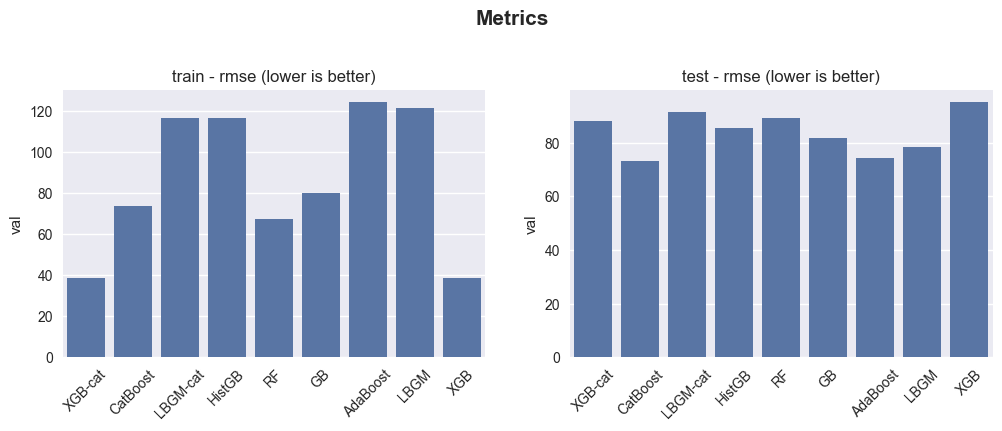

In [12]:
metrics_models = []

def calc_metrics(split: pl.DataFrame, model, verbose: bool = False) -> tuple:
    split = split.clone()
    
    X = split.select(cols_X).to_pandas()
    

    if model['is_cat'] is True:
        for col in cols_cat:
            X[col] = X[col].astype('category')
    
    pcs_pred = np.clip(model['model'].predict(X), a_min=0, a_max=None)
    split = split.with_columns(pl.Series(pcs_pred).alias('pcs_pred'))


    tgt = split.get_column('pcs').to_pandas()
    pred = split.get_column('pcs_pred').to_pandas()
    
    
    rmse = root_mean_squared_error(tgt, pred)
    mape = mean_absolute_percentage_error(tgt, pred)

    if verbose is True:
        print(f"rmse: {rmse:.4f}")
        print(f"mape: {mape:.4f}")

    return rmse, mape

print("== Split: val")
for name, model in models.items():
    print(f"Start: {name}")

    rmse, mape = calc_metrics(test, model)
    metrics_models.append({'model': name, 'val': rmse, 'split': 'test', 'metric': 'rmse'})
    metrics_models.append({'model': name, 'val': mape, 'split': 'test', 'metric': 'mape'})


print("== Split: train")
for name, model in models.items():
    print(f"Start: {name}")

    rmse, mape = calc_metrics(train, model)
    metrics_models.append({'model': name, 'val': rmse, 'split': 'train', 'metric': 'rmse'})
    metrics_models.append({'model': name, 'val': mape, 'split': 'train', 'metric': 'mape'})



# Visualize
metrics = pd.DataFrame.from_records(metrics_models)

fig = plt.figure(figsize=(12, 8))
fig.suptitle("Metrics", fontsize=15, fontweight='bold')
fig.subplots_adjust(wspace=0.2, hspace=0.3)

for i, (split, metric) in enumerate(product(['train', 'test'], ['rmse'])):
    df = metrics[(metrics['split'] == split) & (metrics['metric'] == metric)]

    ax = fig.add_subplot(2, 2, i+1)
    sns.barplot(df, x='model', y='val', ax=ax)
    description = "lower" if metric == "rmse" else "higher"
    ax.set_title(f"{split} - {metric} ({description} is better)")
    ax.set_xlabel("")
    ax.tick_params(axis='x', labelrotation = 45)


## Analyze predictions

In [13]:
best_model = 'CatBoost'

In [14]:
metrics[metrics['model'] == best_model]

,model,val,split,metric
2,CatBoost,73.026780,test,rmse
3,CatBoost,0.067748,test,mape
20,CatBoost,73.532534,train,rmse
21,CatBoost,0.057812,train,mape


### Feature importances

<Axes: xlabel='importance', ylabel='name'>

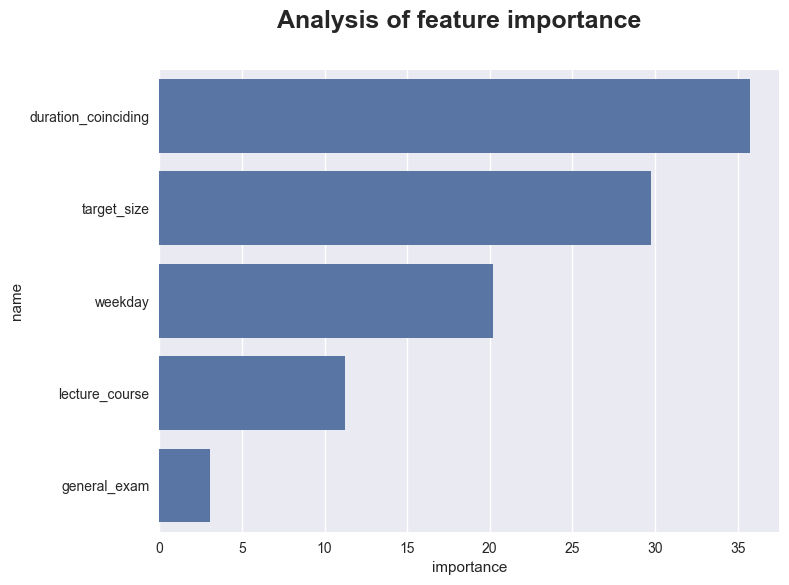

In [22]:
feat_imp = pd.DataFrame({
    'name': Xtrain.columns,
    'importance': models[best_model]['model'].feature_importances_
})

feat_imp.sort_values(by='importance', ascending=False, inplace=True)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
fig.suptitle("Analysis of feature importance", fontsize=18, fontweight='bold')
sns.barplot(feat_imp[:20], y='name', x='importance', ax=ax)

### Prediction distribution

In [16]:
pcs_pred = np.clip(models[best_model]['model'].predict(Xtest), a_min=0, a_max=None)
test = test.with_columns(pl.Series(pcs_pred).alias('pcs_pred'))

test.head()


date,target_size,duration_coinciding,lab,training_group,seminar,lecture_course,course,other,homework,general_exam,field_course,online_course,exam,course_exam,weekday,pcs,pcs_pred
date,i64,f64,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,i8,i64,f64
2024-09-03,3833,1.263736,4,9,4,65,6,3,0,0,0,0,0,0,2,994,968.761362
2024-09-18,3920,1.373786,4,25,5,58,8,1,0,1,0,1,0,0,3,959,923.887938
2024-09-12,4247,1.266055,6,42,5,47,9,0,0,0,0,0,0,0,4,944,925.394974
2024-09-09,4005,1.309524,2,10,1,67,3,1,0,0,0,0,0,0,1,995,989.211467
2024-09-06,2260,1.596774,5,20,4,31,1,1,0,0,0,0,0,0,5,894,820.16636


<Axes: xlabel='value'>

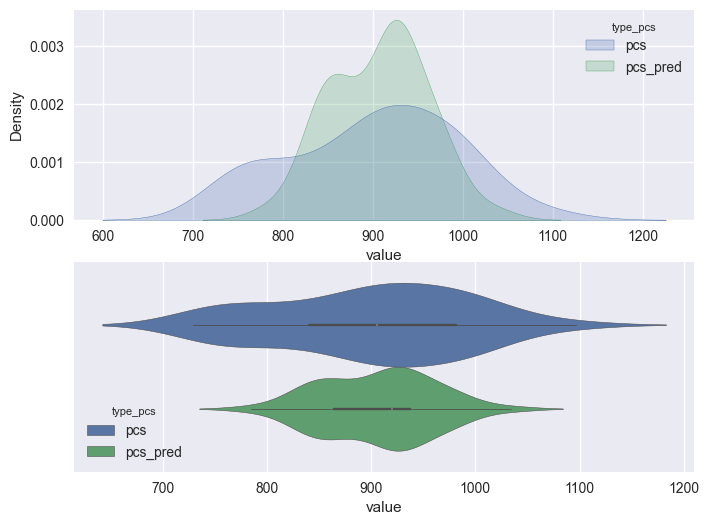

In [17]:
df = (
    test
    .select('pcs', 'pcs_pred')
    
    .unpivot(on=['pcs', 'pcs_pred'], variable_name='type_pcs')
)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(211)
sns.kdeplot(df, x='value', hue='type_pcs', ax=ax, fill=True)

ax = fig.add_subplot(212)
sns.violinplot(df, x='value', hue='type_pcs', ax=ax, fill=True)

<Axes: xlabel='diff'>

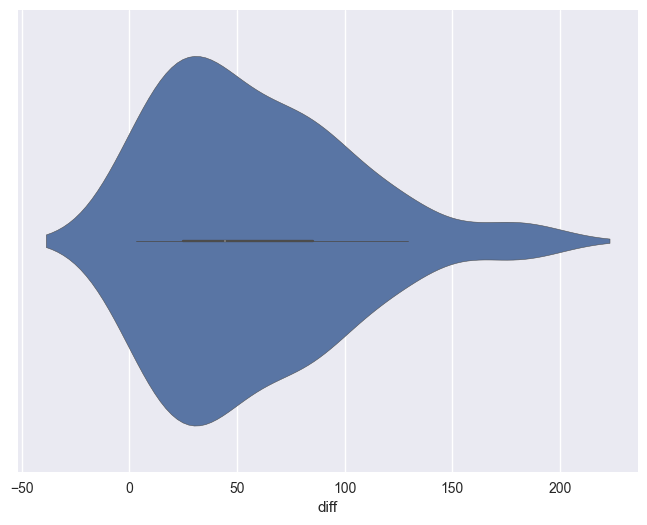

In [18]:
df = (
    test
    .with_columns((pl.col('pcs_pred') - pl.col('pcs')).abs().alias('diff'))
)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
sns.violinplot(x=df['diff'], ax=ax, fill=True)

In [19]:
# Analyze entries yielding most serious errors (diff >= 100)
df = (
    test
    .with_columns((pl.col('pcs_pred') - pl.col('pcs')).abs().alias('diff'))

    .filter(pl.col('diff') >= 100)
)

df.head()

date,target_size,duration_coinciding,lab,training_group,seminar,lecture_course,course,other,homework,general_exam,field_course,online_course,exam,course_exam,weekday,pcs,pcs_pred,diff
date,i64,f64,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,i8,i64,f64,f64
2024-10-03,4048,1.314286,6,41,5,43,10,0,0,0,0,0,0,0,4,744,873.278764,129.278764
2024-10-09,3773,1.40404,4,25,3,56,9,1,0,0,0,1,0,0,3,729,910.302023,181.302023
2024-09-30,4414,1.336957,3,8,3,68,8,0,0,0,0,0,0,2,1,1096,974.03645,121.96355
2024-10-16,3722,1.383838,4,25,3,57,8,1,0,0,0,1,0,0,3,742,921.102695,179.102695
2024-10-31,3675,1.247664,6,38,6,55,2,0,0,0,0,0,0,0,4,850,969.978911,119.978911


In [20]:
# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(211)
# sns.violinplot(df['target_size'], ax=ax, orient='h')
# sns.violinplot(test['target_size'], ax=ax, orient='h')

# ax = fig.add_subplot(212)
# sns.violinplot(df['duration_coinciding'], ax=ax, orient='h')
# sns.violinplot(test['duration_coinciding'], ax=ax, orient='h')

# => Distribution of 'target_size' and 'duration_coinciding' of whole split and of seriously erroneous entries are quite overlapping => Reason for incorrect prediction may not derive from 'target_size' and 'duration_coinciding'

In [21]:
(
    df
    .with_columns(pl.col('date').dt.weekday().alias('weekday'))
    .select(pl.col('weekday').value_counts())
)

weekday
struct[2]
"{4,3}"
"{1,1}"
"{3,2}"
